In [32]:
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
import pandas as pd
import numpy as np
import scipy.stats as stats
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import pickle
import sklearn
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import gc
# import sentence_transformers
plt.style.use('ggplot')
#plt.style.use('seaborn-v0_8-dark-palette')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "Helvetica"
})
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [33]:
gene_info_table = pd.read_csv('./input_data/gene_info_table.csv')

In [34]:
with open(f"./data/GenePT_gene_embedding_ada_text.pickle", "rb") as fp:
    GPT_3_5_gene_embeddings = pickle.load(fp)

KeyboardInterrupt: 

In [ ]:
# Import dual embeddings
dual_embeddings = pd.read_csv('./data/e2e_projected-attn-cls_uniqueTrue_33524_2026-01-14.csv', index_col=0)


In [ ]:
dual_embeddings.columns

Index(['evo2_proj', 'genept_proj', 'mean_evo2', 'mean_genept', 'transcript_id',
       'gene_id', 'gene_name', 'gene_type', 'EntrezGeneID', 'ccdsid', 'chrom',
       'start', 'end', 'strand'],
      dtype='object')

In [39]:
# evo2 proj is where evo2 attends to genept
evo2_proj = dual_embeddings[['gene_name','evo2_proj']]
evo2_proj['evo2_proj'] = evo2_proj['evo2_proj'].apply(lambda x: np.fromstring(x.strip("[]"), sep=','))
evo2_proj_dict = dict(zip(evo2_proj['gene_name'], evo2_proj['evo2_proj']))

# genept proj is where genept attends to evo2
genept_proj = dual_embeddings[['gene_name','genept_proj']]
genept_proj['genept_proj'] = genept_proj['genept_proj'].apply(lambda x: np.fromstring(x.strip("[]"), sep=','))
genept_proj_dict = dict(zip(genept_proj['gene_name'], genept_proj['genept_proj']))

# mean evo2 is the mean of the evo2 embeddings only
mean_evo2 = dual_embeddings[['gene_name','mean_evo2']]
mean_evo2['mean_evo2'] = mean_evo2['mean_evo2'].apply(lambda x: np.fromstring(x.strip("[]"), sep=','))
mean_evo2_dict = dict(zip(mean_evo2['gene_name'], mean_evo2['mean_evo2']))

# concat evo2 and genept embeddings
concat_evo2_genept_dict = {}
for i,row in dual_embeddings.iterrows():
    evo2_emb = np.fromstring(row['evo2_proj'].strip("[]"), sep=',')
    genept_emb = np.fromstring(row['genept_proj'].strip("[]"), sep=',')
    concat_emb = np.concatenate((evo2_emb, genept_emb))
    concat_evo2_genept_dict[row['gene_name']] = concat_emb

C:\Users\jethr\AppData\Local\Temp\ipykernel_32304\2956792927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evo2_proj['evo2_proj'] = evo2_proj['evo2_proj'].apply(lambda x: np.fromstring(x.strip("[]"), sep=','))
C:\Users\jethr\AppData\Local\Temp\ipykernel_32304\2956792927.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genept_proj['genept_proj'] = genept_proj['genept_proj'].apply(lambda x: np.fromstring(x.strip("[]"), sep=','))
C:\Users\jethr\AppData\Local\Temp\ipykernel_32304\2956792927.py:13: Sett

In [40]:
# dimension prints
print("Embedding dimensions:")
print("Original embeddings:", len(GPT_3_5_gene_embeddings['7SK']))
print("Evo2 projected embeddings:", evo2_proj_dict['7SK'].shape)
print("GenePT projected embeddings:", genept_proj_dict['7SK'].shape)
print("Mean Evo2 embeddings:", mean_evo2_dict['7SK'].shape)
print("Concat Evo2 + GenePT embeddings:", concat_evo2_genept_dict['7SK'].shape)

Embedding dimensions:
Original embeddings: 1536
Evo2 projected embeddings: (256,)
GenePT projected embeddings: (256,)
Mean Evo2 embeddings: (1920,)
Concat Evo2 + GenePT embeddings: (512,)


In [7]:
# Create random embeddings as negative controls
np.random.seed(2023)
N_DIM = 1536
fake_pretrain_embed = dict()
for key in evo2_proj_dict.keys():
    fake_pretrain_embed[key] = np.random.normal(size=(N_DIM))

In [ ]:
# Create a new column "gpt_embed" with default value as False
gene_info_table['gpt_embed'] = False

# Update the new column based on the condition
def check_embedding(row):
    gene = row['gene_name']
    if gene in GPT_3_5_gene_embeddings:
        embed_value = GPT_3_5_gene_embeddings[gene]
        if np.any(embed_value != 0):
            return True
    return False

gene_info_table['gpt_embed'] = gene_info_table.apply(check_embedding, axis=1)
# Create a subset where gpt_embed is True
subset = gene_info_table[gene_info_table['gpt_embed']]

# Find gene_type elements with occurrences > 50 (in this case, just for demonstration, I'll use > 2)
gene_type_counts = subset['gene_type'].value_counts()
common_gene_types = gene_type_counts[gene_type_counts > 75].index

# Create a final subset of the original DataFrame with only these gene_type elements
final_subset = gene_info_table[(gene_info_table['gene_type'].isin(common_gene_types))\
                               &(gene_info_table['gpt_embed'])]

# let's do a very simple classification for final_subset
X_list = []
y_list = []
# Iterate through rows of final_subset
for index, row in final_subset.iterrows():
    gene_name = row['gene_name']
    gene_type = row['gene_type']
    # Add the embedding from the dictionary to the x list, but to only those that only eixst in the other dicts
    if gene_name in genept_proj_dict:
        X_list.append(GPT_3_5_gene_embeddings[gene_name])

    # Add the gene_type to the y list
        y_list.append(gene_type)

In [42]:
## Prepare the dataset

# Genept key
genept_X_list = []
genept_y_list = []
# Iterate through rows of final_subset
for index, row in final_subset.iterrows():
    gene_name = row['gene_name']
    gene_type = row['gene_type']
    # Add the embedding from the dictionary to the x list
    if gene_name in genept_proj_dict:
        genept_X_list.append(genept_proj_dict[gene_name])

    # Add the gene_type to the y list
        genept_y_list.append(gene_type)
# evo2 key
evo2_X_list = []
evo2_y_list = []
# Iterate through rows of final_subset
for index, row in final_subset.iterrows():
    gene_name = row['gene_name']
    gene_type = row['gene_type']
    # Add the embedding from the dictionary to the x list
    if gene_name in evo2_proj_dict:
        evo2_X_list.append(evo2_proj_dict[gene_name])

    # Add the gene_type to the y list
        evo2_y_list.append(gene_type)

# mean_evo2
mean_evo2_X_list = []
mean_evo2_y_list = []
# Iterate through rows of final_subset
for index, row in final_subset.iterrows():
    gene_name = row['gene_name']
    gene_type = row['gene_type']
    # Add the embedding from the dictionary to the x list
    if gene_name in mean_evo2_dict:
        mean_evo2_X_list.append(mean_evo2_dict[gene_name])

    # Add the gene_type to the y list
        mean_evo2_y_list.append(gene_type)

# concat evo2 and genept
concat_evo2_genept_X_list = []
concat_evo2_genept_y_list = []
# Iterate through rows of final_subset
for index, row in final_subset.iterrows():
    gene_name = row['gene_name']
    gene_type = row['gene_type']
    # Add the embedding from the dictionary to the x list
    if gene_name in concat_evo2_genept_dict:
        concat_evo2_genept_X_list.append(concat_evo2_genept_dict[gene_name])
    # Add the gene_type to the y list
        concat_evo2_genept_y_list.append(gene_type)

In [43]:
np.random.seed(2023)
from sklearn.model_selection import train_test_split

# Split the data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_list, y_list, test_size=0.30, random_state=2023)
evo2_X_train, evo2_X_test, evo2_y_train, evo2_y_test = train_test_split(evo2_X_list, evo2_y_list, test_size=0.30, random_state=2023)
genept_X_train, genept_X_test, genept_y_train, genept_y_test = train_test_split(genept_X_list, genept_y_list, test_size=0.30, random_state=2023)

# Verify the split
print(f"Training set size (X_train): {len(X_train)}")
print(f"Test set size (X_test): {len(X_test)}")
# Logistic Regression - original
lr = LogisticRegression(max_iter=100)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
gc.collect()

# Logistic Regression - evo2
evo2_lr = LogisticRegression(max_iter=100)
evo2_lr.fit(evo2_X_train, evo2_y_train)
evo2_y_pred_lr = evo2_lr.predict(evo2_X_test)
gc.collect()

# Logistic Regression - genept
genept_lr = LogisticRegression(max_iter=100)
genept_lr.fit(genept_X_train, genept_y_train)
genept_y_pred_lr = genept_lr.predict(genept_X_test)
gc.collect()

# Logistic regression - mean evo2
mean_evo2_lr = LogisticRegression(max_iter=100)
mean_evo2_lr.fit(mean_evo2_X_list, mean_evo2_y_list)
mean_evo2_y_pred_lr = mean_evo2_lr.predict(mean_evo2_X_list)
gc.collect()

# Logistic regression - concat evo2 and genept
concat_evo2_genept_lr = LogisticRegression(max_iter=100)
concat_evo2_genept_lr.fit(concat_evo2_genept_X_list, concat_evo2_genept_y_list)
concat_evo2_genept_y_pred_lr = concat_evo2_genept_lr.predict(concat_evo2_genept_X_list)
gc.collect()

Training set size (X_train): 22529
Test set size (X_test): 9656


c:\Users\jethr\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\jethr\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.htm

62

In [44]:
print("Logistic Regression Accuracies:")
print("Original Embeddings:")
print(sklearn.metrics.accuracy_score(y_pred_lr,y_test))
print("Evo2 Projected Embeddings:")
print(sklearn.metrics.accuracy_score(evo2_y_pred_lr,evo2_y_test))
print("GenePT Projected Embeddings:")
print(sklearn.metrics.accuracy_score(genept_y_pred_lr,genept_y_test))
print("Mean Evo2 Embeddings:")
print(sklearn.metrics.accuracy_score(mean_evo2_y_pred_lr,mean_evo2_y_list))
print("Concat Evo2 + GenePT Embeddings:")
print(sklearn.metrics.accuracy_score(concat_evo2_genept_y_pred_lr,concat_evo2_genept_y_list))

Logistic Regression Accuracies:
Original Embeddings:
0.941072908036454
Evo2 Projected Embeddings:
0.9442833471416736
GenePT Projected Embeddings:
0.9199461474730737
Mean Evo2 Embeddings:
0.8049401895292838
Concat Evo2 + GenePT Embeddings:
0.9509398788255399


In [58]:
# get expression
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_normalized_confusion_matrix(y_true, y_pred, classes, title=None):
    """
    Plot a normalized confusion matrix using seaborn.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize by row
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # replace nan with 0
    cm_normalized = cm_normalized * 100  # convert to percentage

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.0f', annot_kws={'fontsize': 13.5},
                cmap='Blues', xticklabels=classes, yticklabels=classes,cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

In [59]:
y_pred_lr

array(['protein_coding', 'protein_coding', 'protein_coding', ...,
       'protein_coding', 'pseudogene', 'protein_coding'], dtype='<U20')

<Figure size 600x600 with 0 Axes>

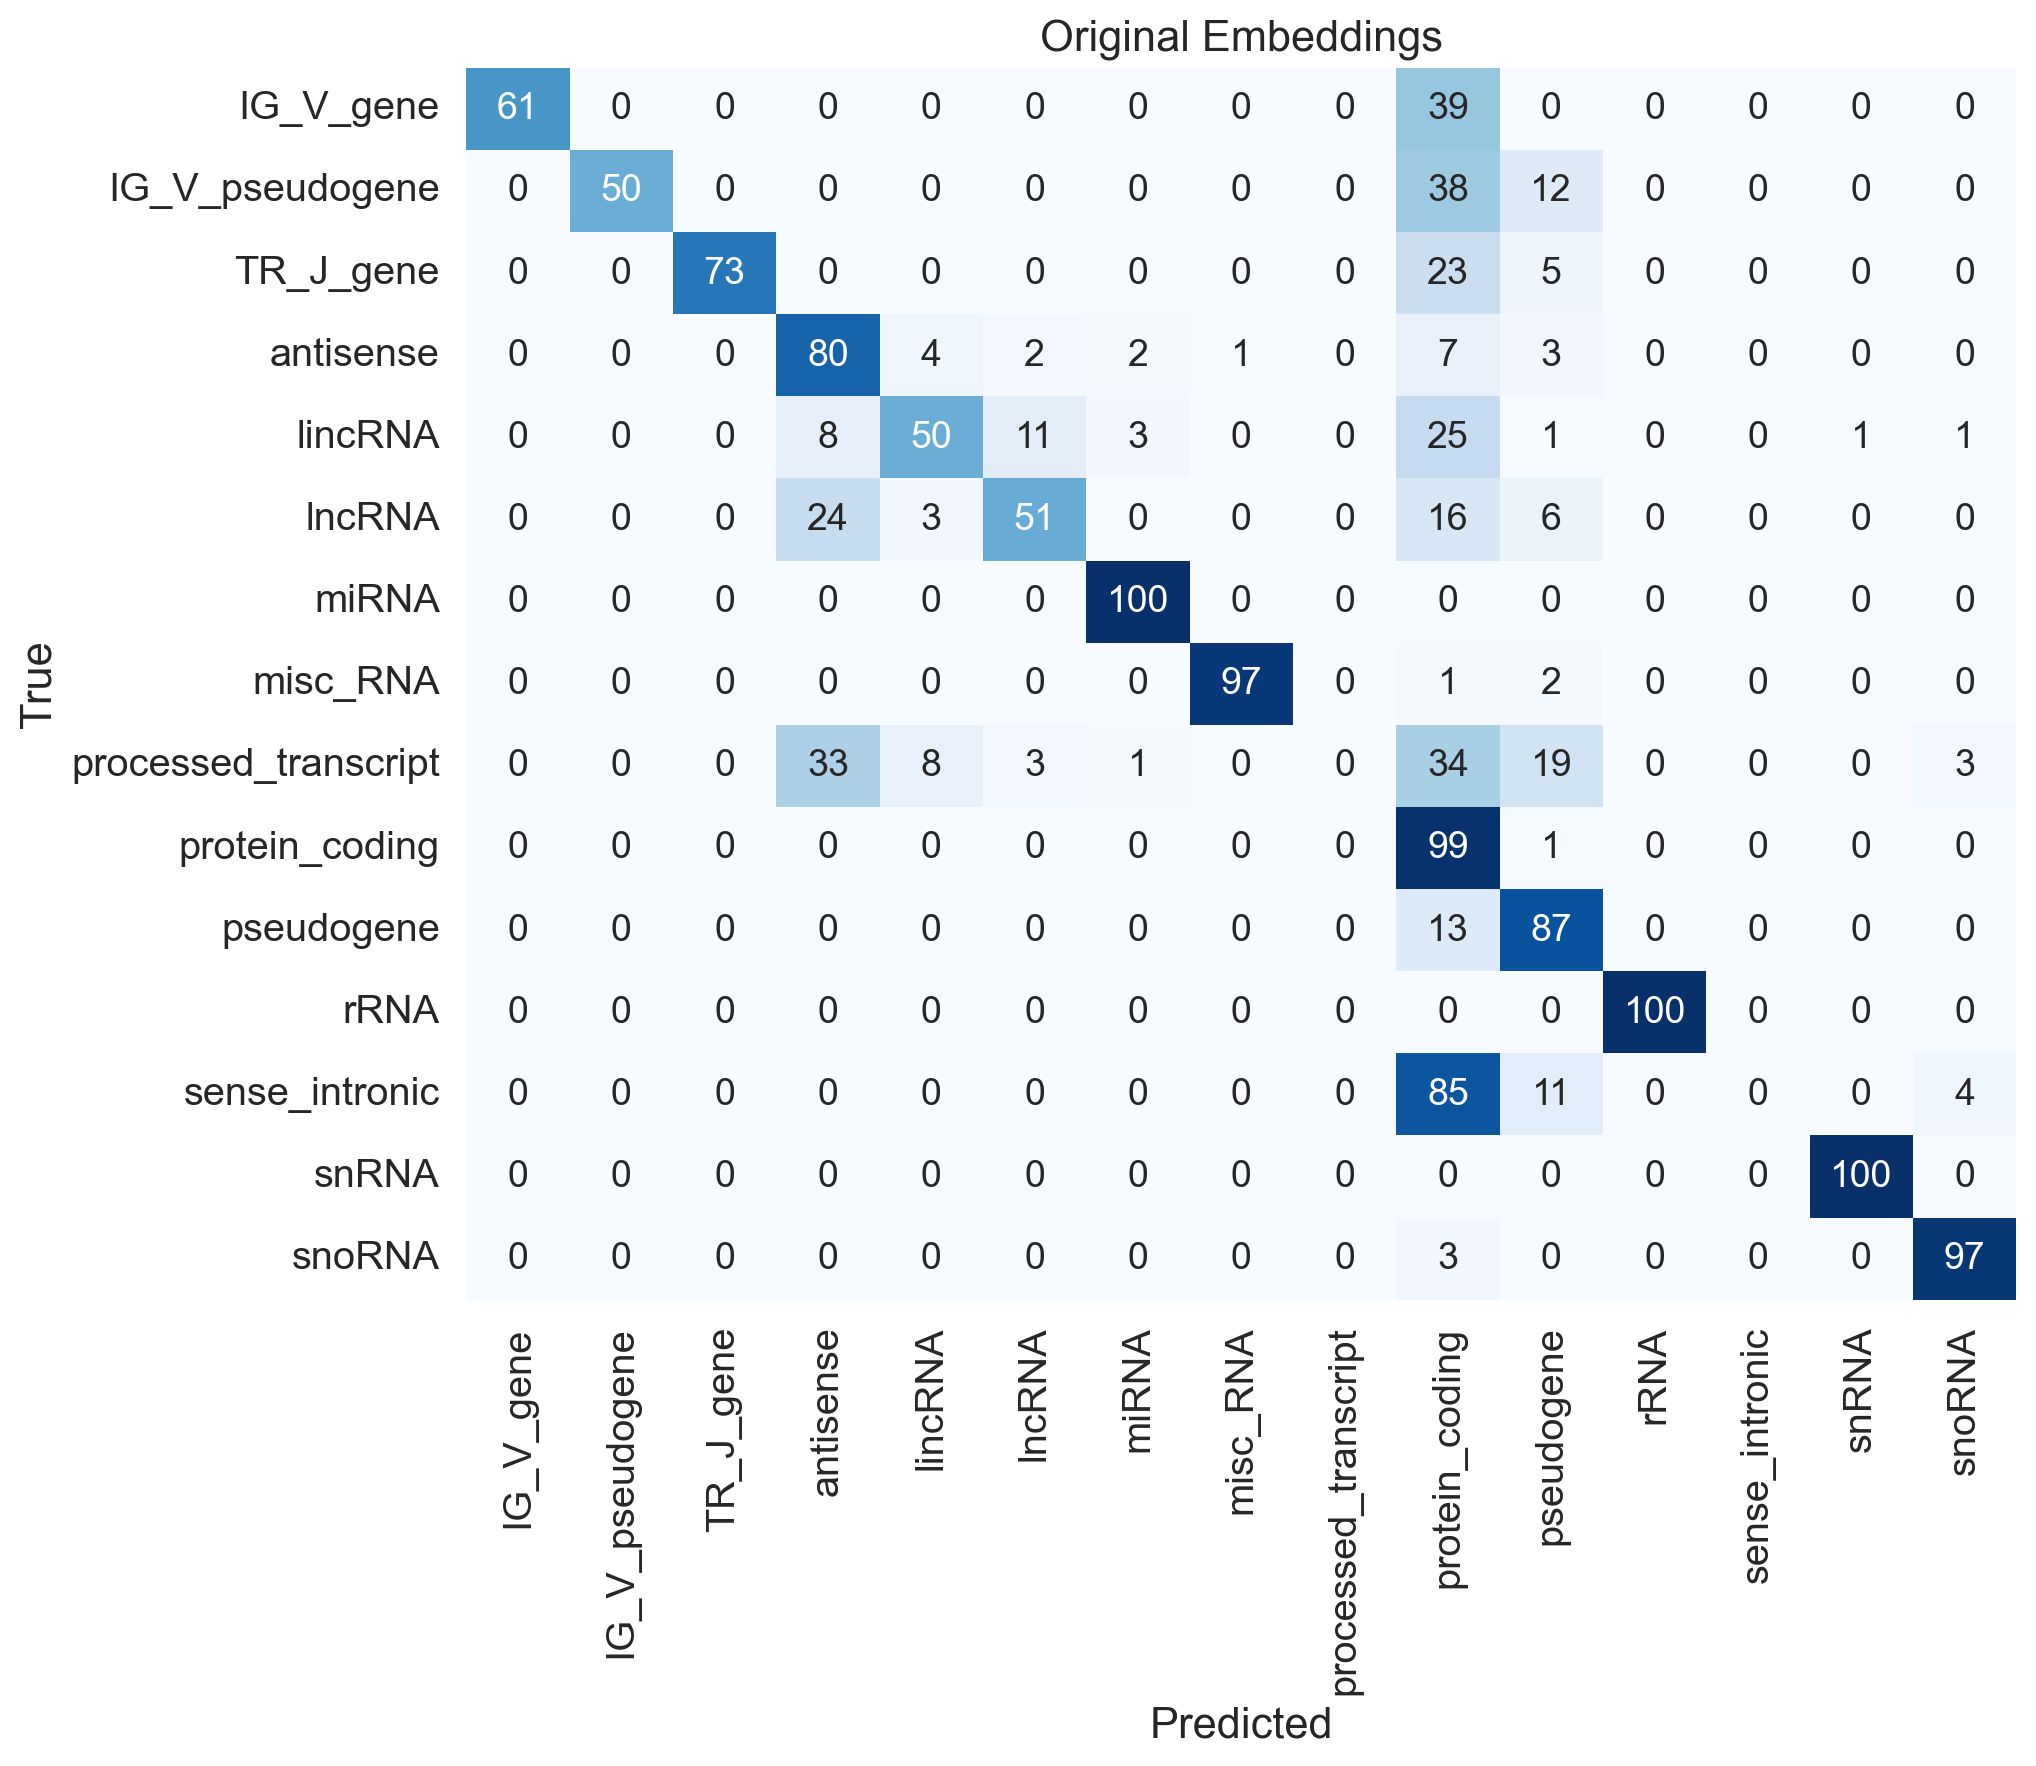

<Figure size 600x600 with 0 Axes>

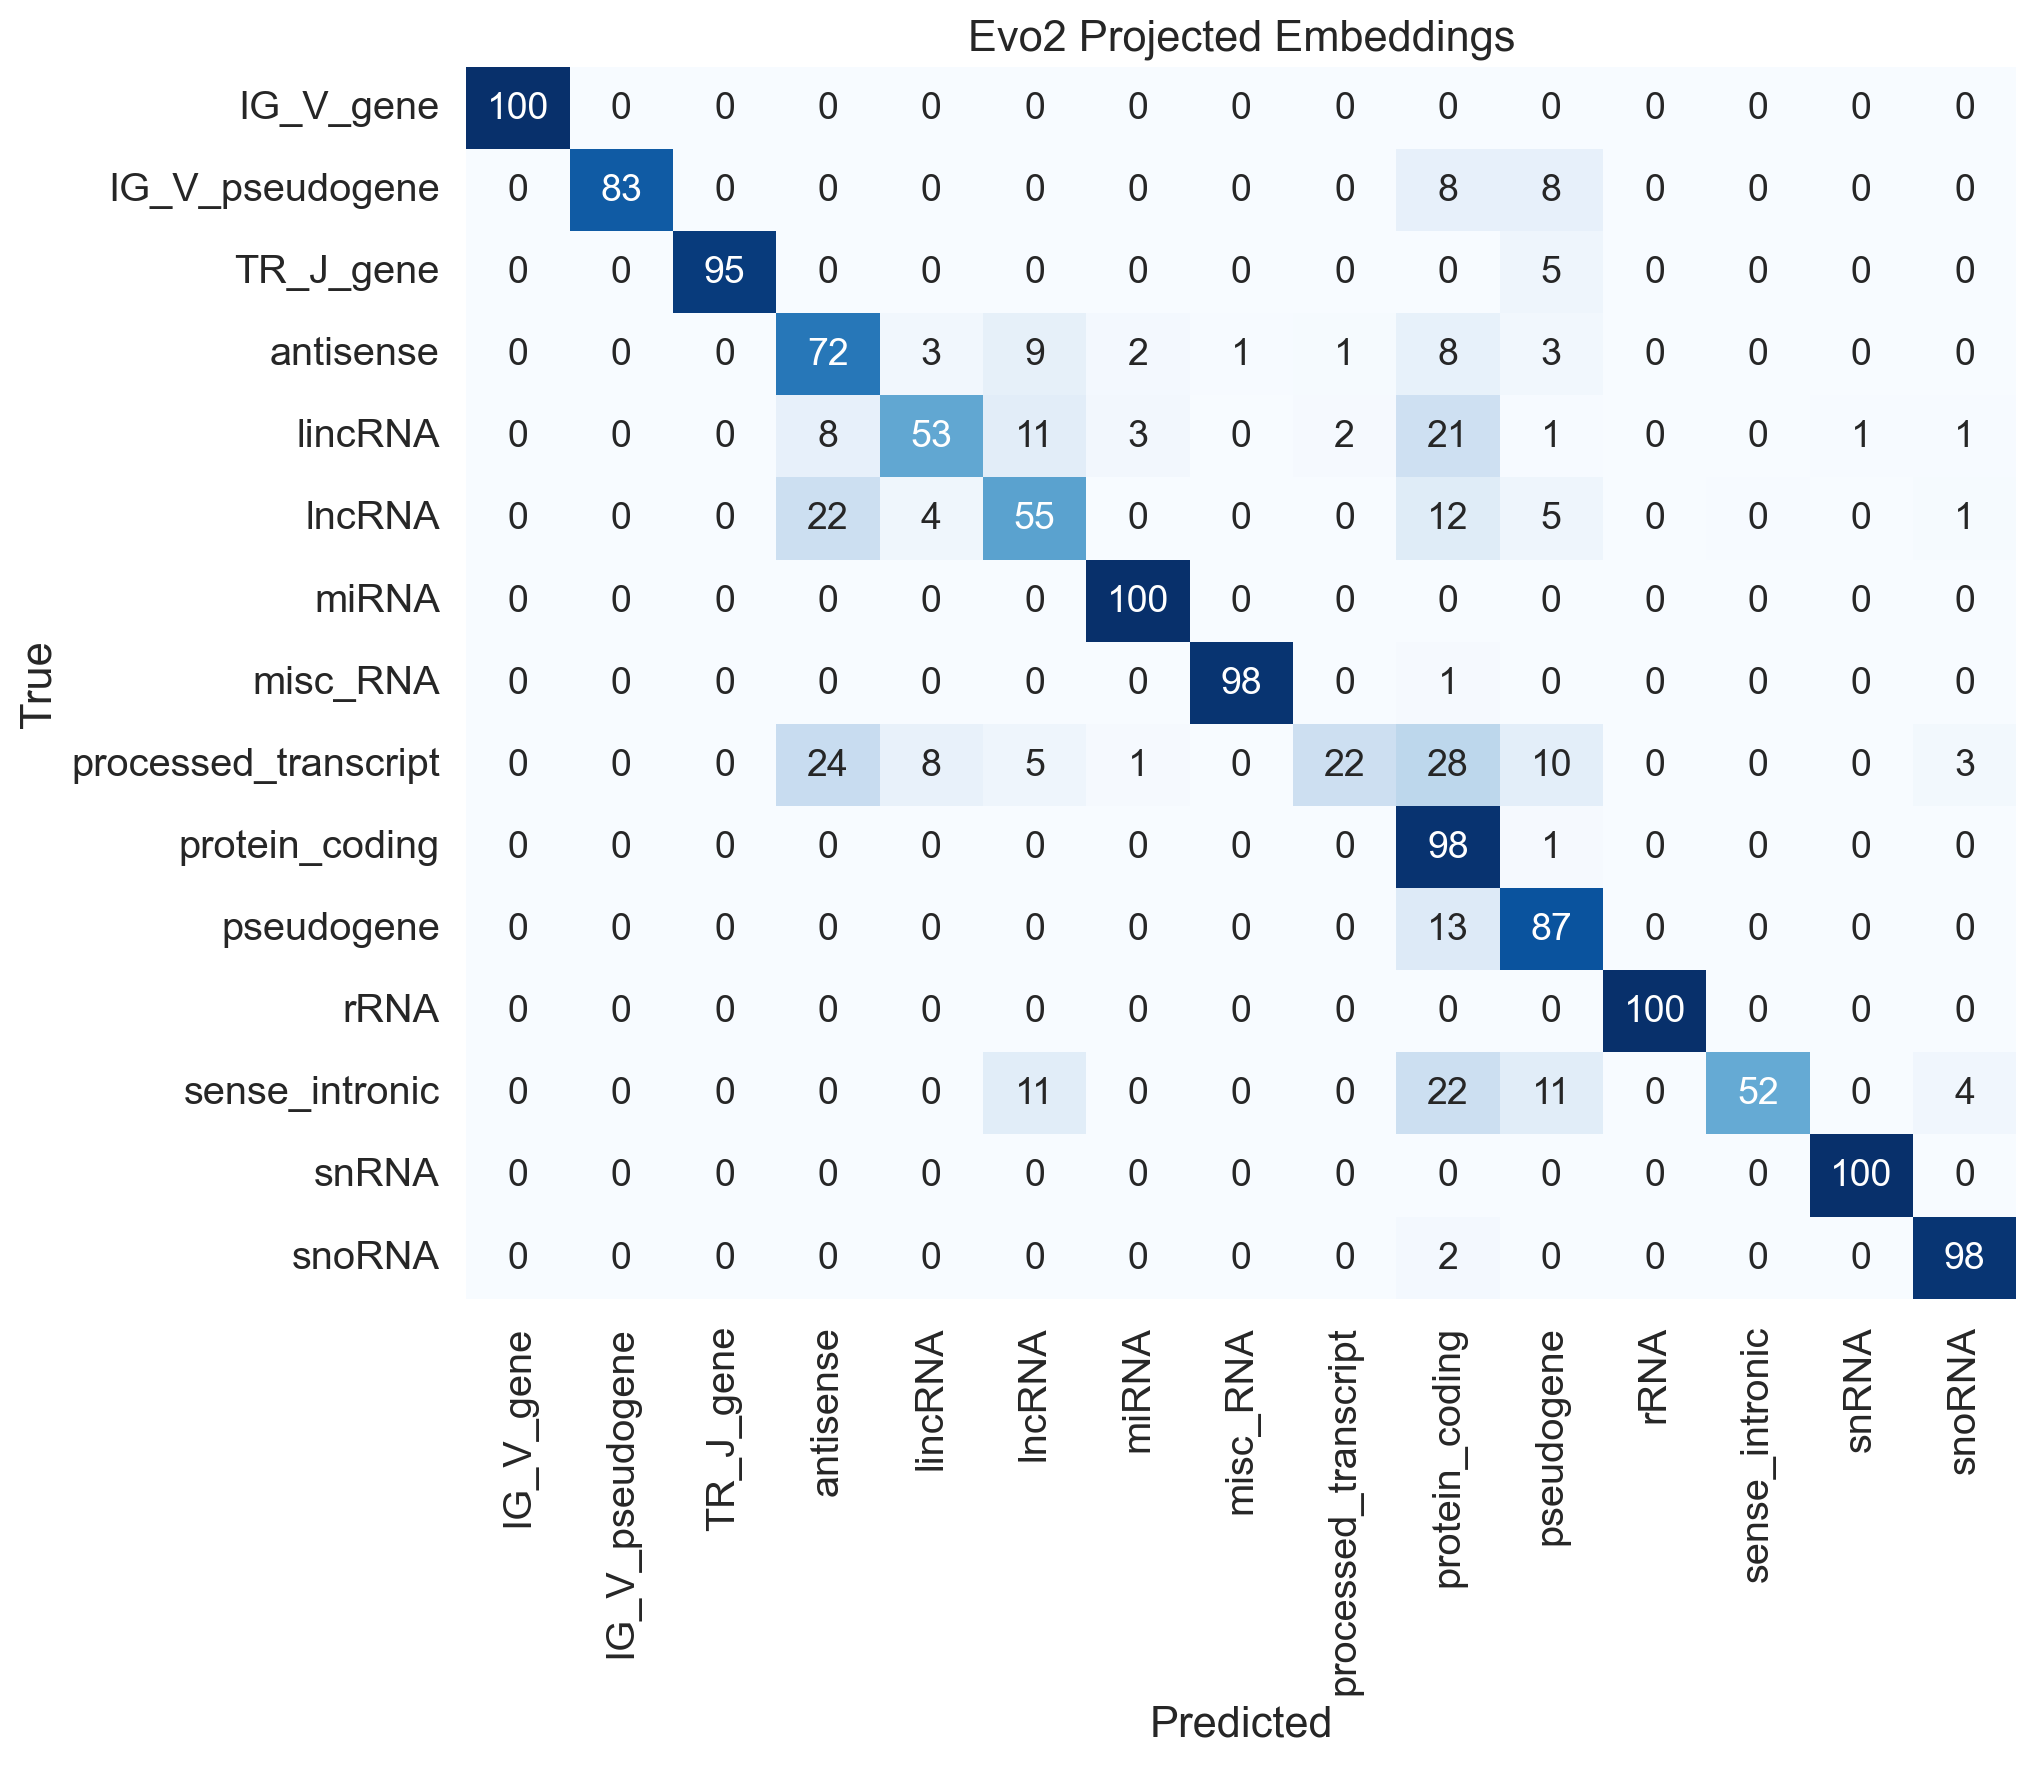

<Figure size 600x600 with 0 Axes>

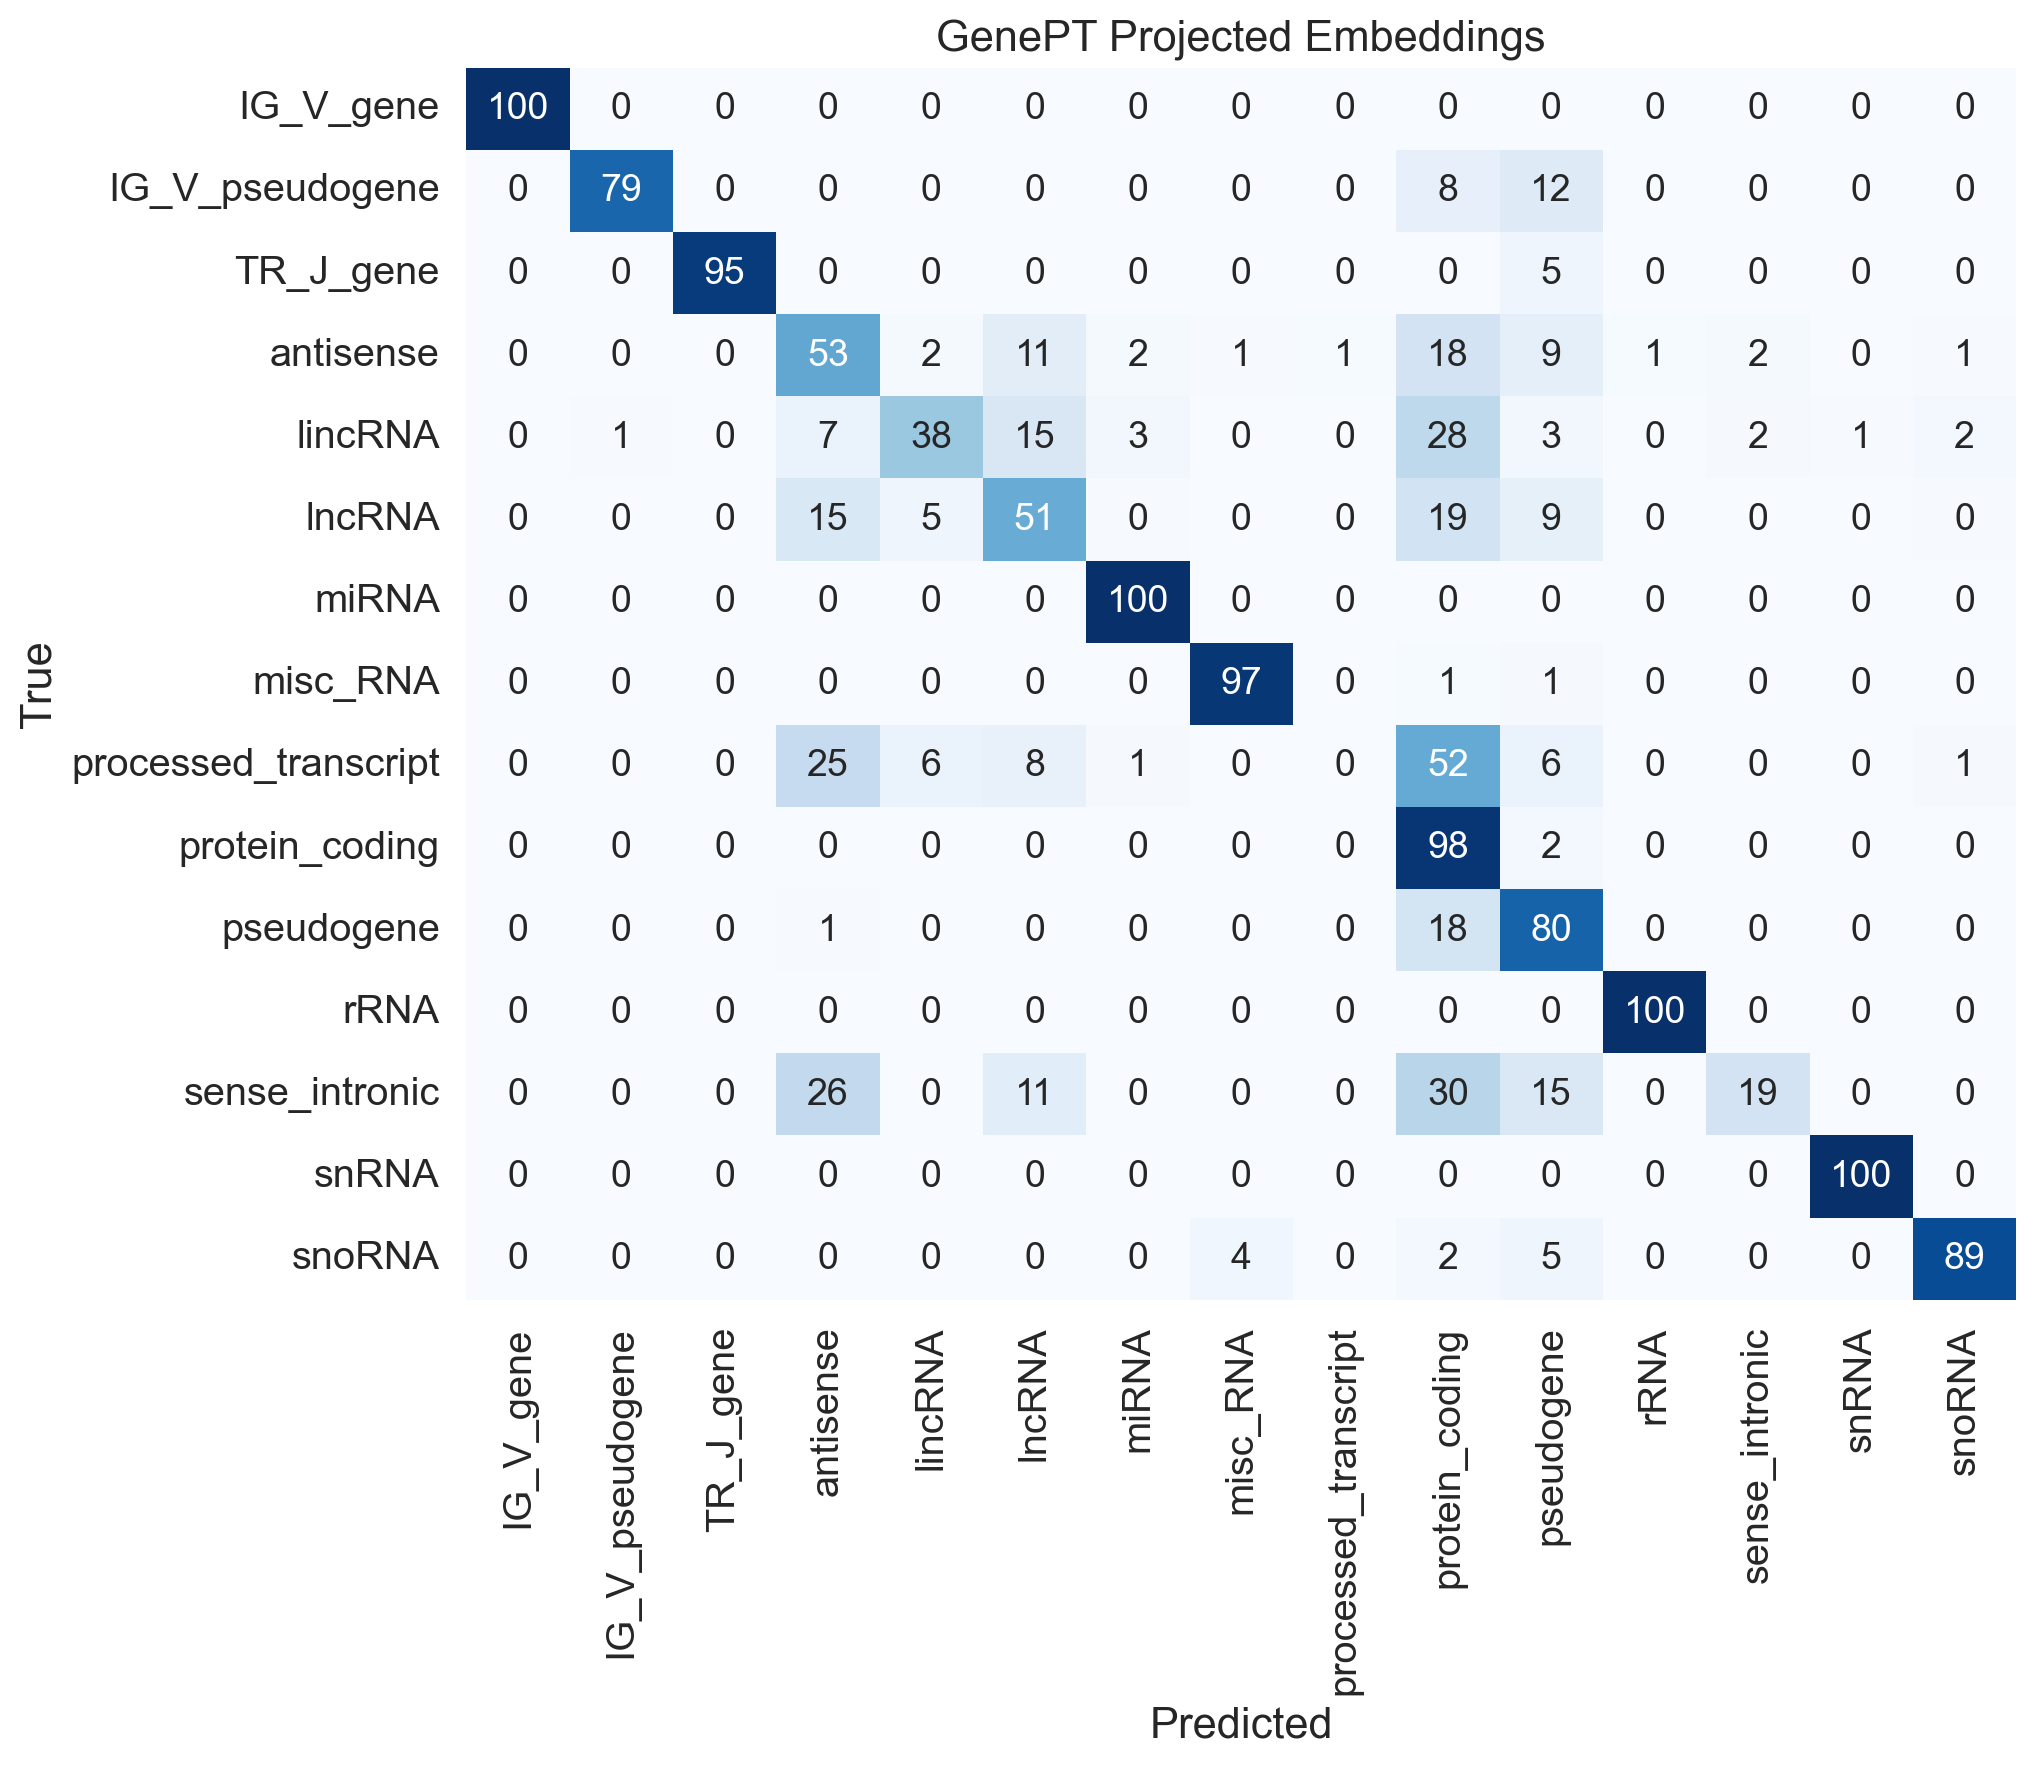

<Figure size 600x600 with 0 Axes>

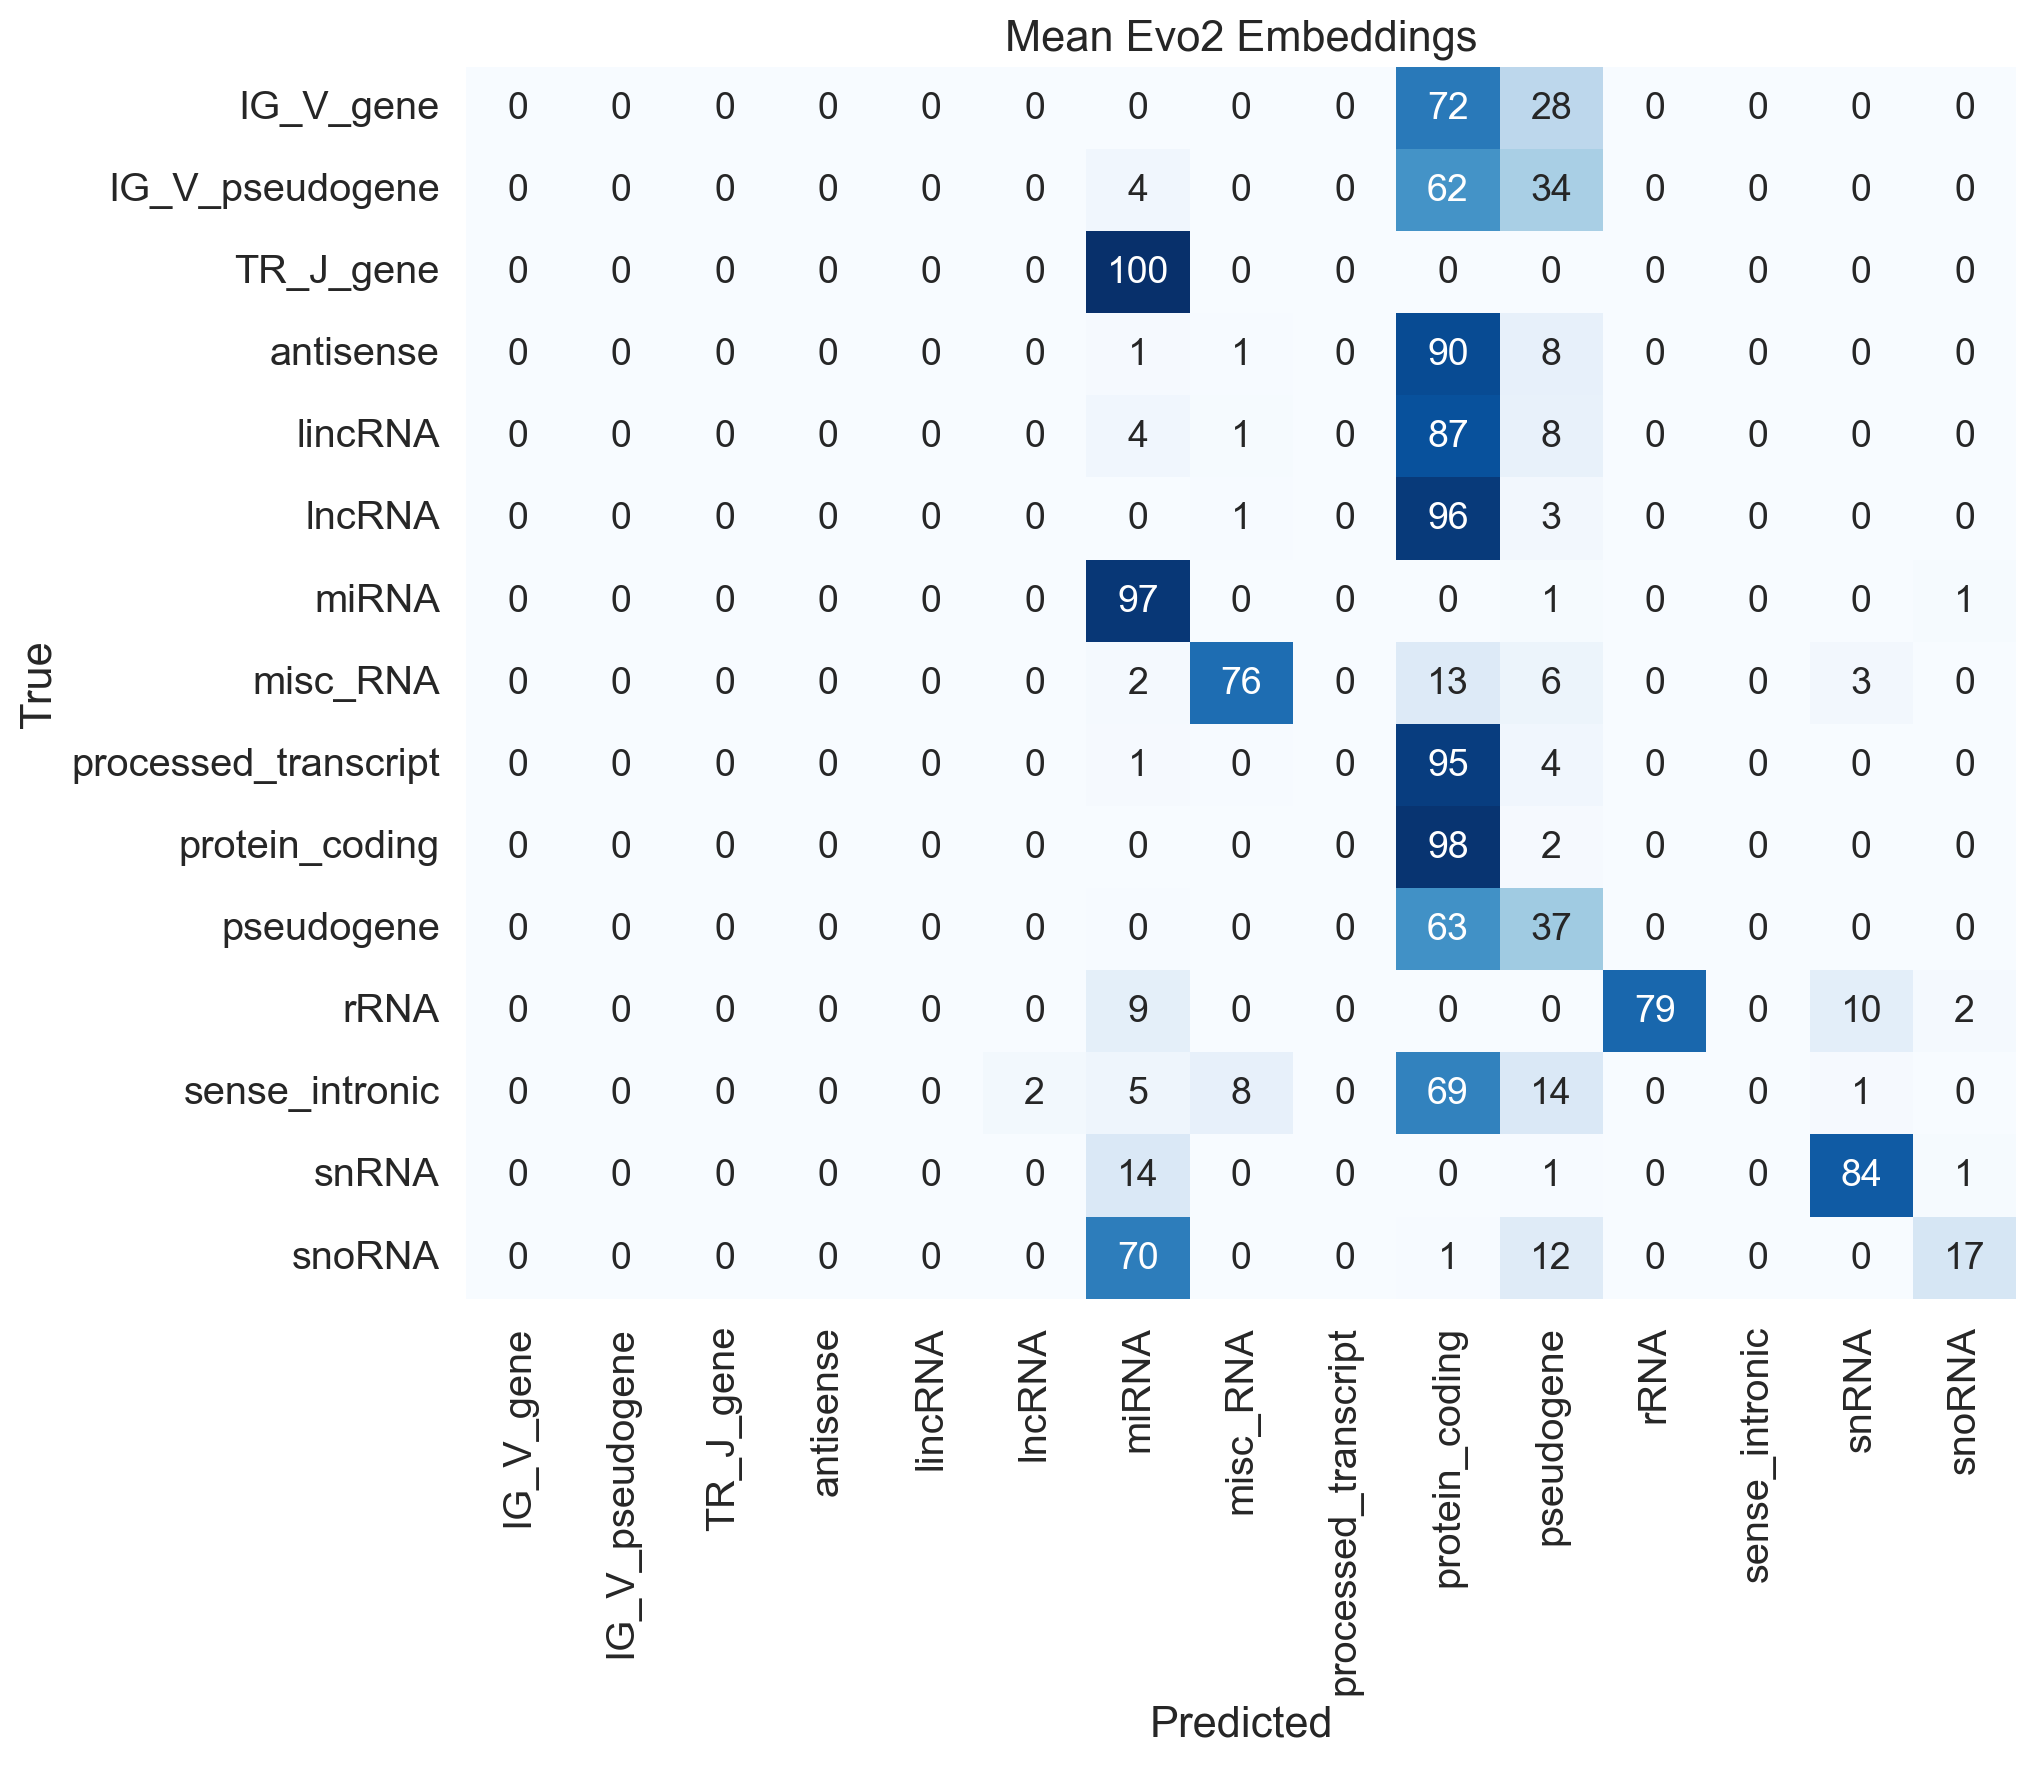

<Figure size 600x600 with 0 Axes>

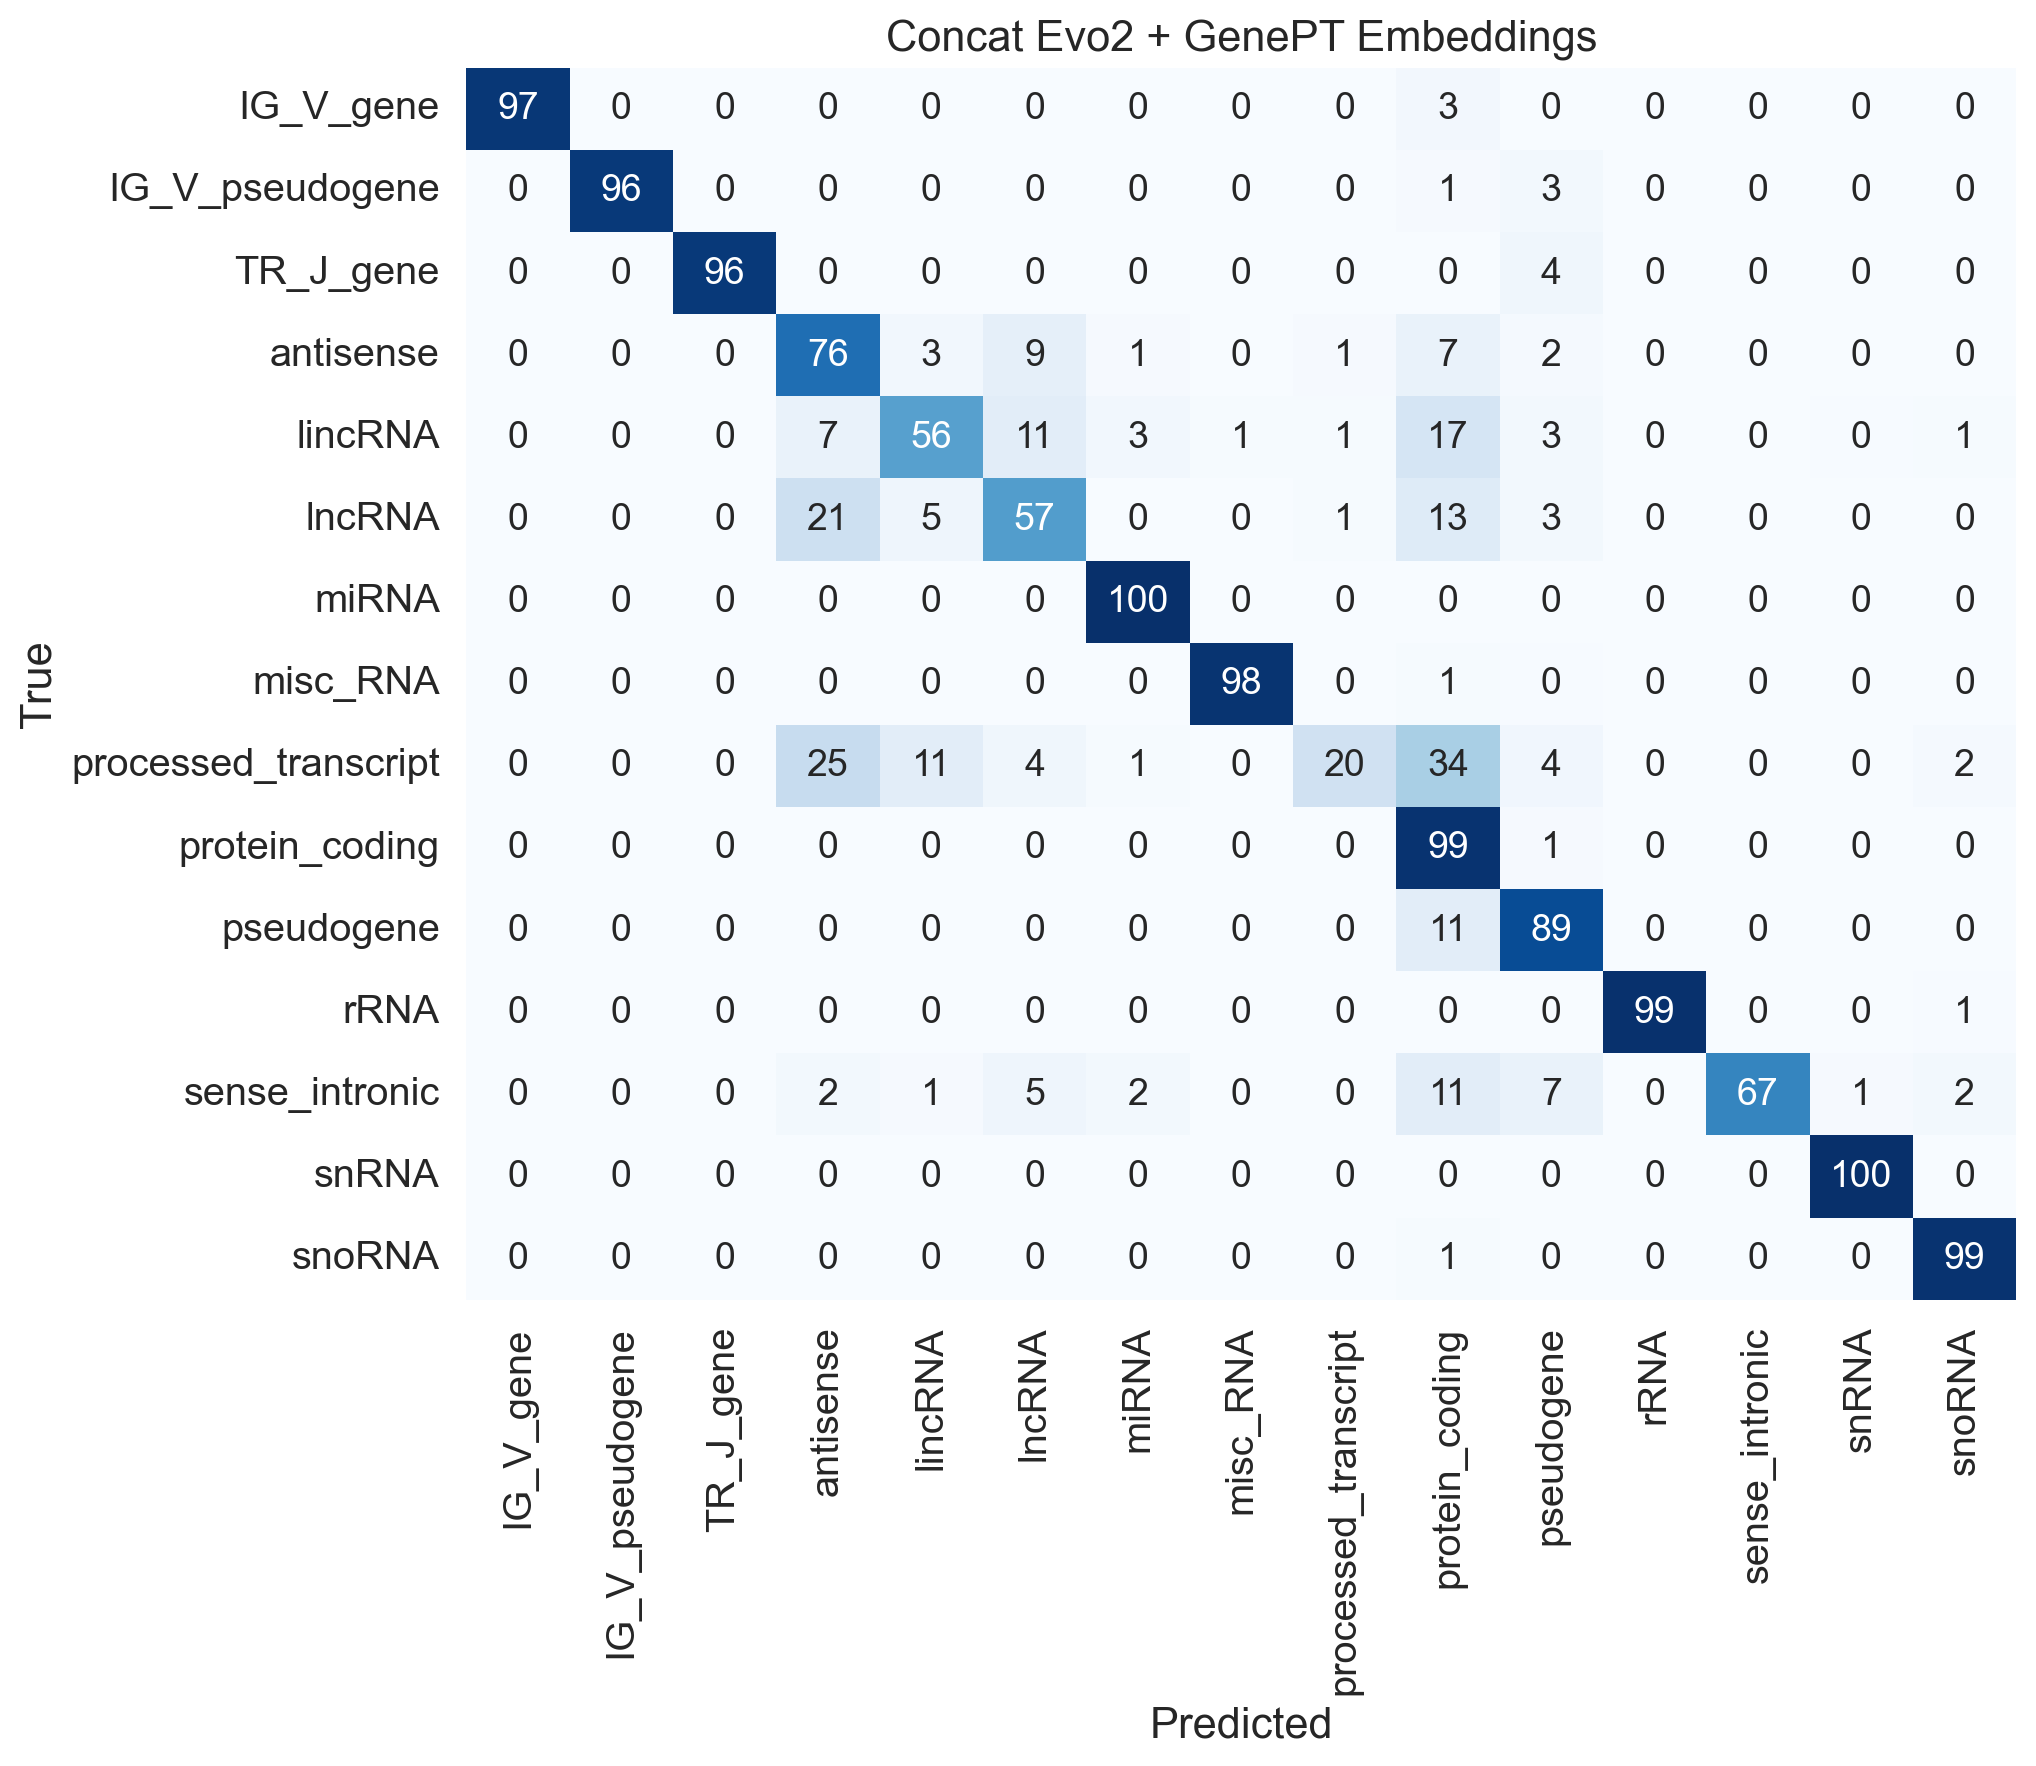

In [60]:
plt.figure(figsize=(6,6))
sns.set(font_scale=1.3)
plot_normalized_confusion_matrix(np.array(y_test),y_pred_lr,np.unique(y_list), title='Original Embeddings')


#evo2 proj
plt.figure(figsize=(6,6))
sns.set(font_scale=1.3)
plot_normalized_confusion_matrix(np.array(evo2_y_test),evo2_y_pred_lr,np.unique(evo2_y_list), title='Evo2 Projected Embeddings')


# genept proj
plt.figure(figsize=(6,6))
sns.set(font_scale=1.3)
plot_normalized_confusion_matrix(np.array(genept_y_test),genept_y_pred_lr,np.unique(genept_y_list), title='GenePT Projected Embeddings')


# evo2 mean
plt.figure(figsize=(6,6))
sns.set(font_scale=1.3)
plot_normalized_confusion_matrix(np.array(mean_evo2_y_list),mean_evo2_y_pred_lr,np.unique(mean_evo2_y_list), title='Mean Evo2 Embeddings')


# evo2 + genept concat
plt.figure(figsize=(6,6))
sns.set(font_scale=1.3)
plot_normalized_confusion_matrix(np.array(concat_evo2_genept_y_list),concat_evo2_genept_y_pred_lr,np.unique(concat_evo2_genept_y_list), title='Concat Evo2 + GenePT Embeddings')


## Gene-gene interaction prediction
#### We showcase the gene-gene interaction prediction use case below. The input data can be downloaded from https://github.com/jingcheng-du/Gene2vec repo.

In [48]:
# gene gene interaction
train_text_GGI = pd.read_csv('./data/predictionData/train_text.txt',sep=' ',
                            header=None)
train_label_GGI = pd.read_csv('./data/predictionData/train_label.txt',
                              header=None)
train_text_GGI.columns = ['gene_1','gene_2']
train_label_GGI.columns = ['label']
train_text_GGI_df = pd.concat([train_text_GGI,train_label_GGI], axis=1)

In [49]:
#gene gene interaction
test_text_GGI = pd.read_csv('./data/predictionData/test_text.txt',sep=' ',
                            header=None)
test_label_GGI = pd.read_csv('./data/predictionData/test_label.txt',
                            header=None)
test_text_GGI.columns = ['gene_1','gene_2']
test_label_GGI.columns = ['label']
test_text_GGI_df = pd.concat([test_text_GGI,test_label_GGI], axis=1)

In [50]:
train_text_GGI_df.head()

,gene_1,gene_2,label
0,GPNMB,BAP1,1
1,GPR34,CARD16,0
2,ELF5,TGFB2,1
3,LILRB2,NCR2,1
4,CRMP1,DLX5,1


### We choose a simple featurization scheme by *adding* the emebdding vectors of the two genes together:

In [51]:
# original genept but only add those that share the common genes in evo2 proj
X_array_train = []
y_array_train = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  evo2_proj_dict \
        and row['gene_2'] in GPT_3_5_gene_embeddings:
        X_array_train.append(GPT_3_5_gene_embeddings[row['gene_1']]+\
                             GPT_3_5_gene_embeddings[row['gene_2']])
        y_array_train.append(row['label'])
X_array_train = np.array(X_array_train)
X_array_train = X_array_train.reshape(X_array_train.shape[0],-1)

X_array_test = []
y_array_test = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  evo2_proj_dict \
        and row['gene_2'] in GPT_3_5_gene_embeddings:
        X_array_test.append(GPT_3_5_gene_embeddings[row['gene_1']]+\
                             GPT_3_5_gene_embeddings[row['gene_2']])
        y_array_test.append(row['label'])
X_array_test = np.array(X_array_test)
X_array_test = X_array_test.reshape(X_array_test.shape[0],-1)

# evo2 proj
X_array_train_evo2 = []
y_array_train_evo2 = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  evo2_proj_dict \
        and row['gene_2'] in evo2_proj_dict:
        X_array_train_evo2.append(evo2_proj_dict[row['gene_1']]+\
                             evo2_proj_dict[row['gene_2']])
        y_array_train_evo2.append(row['label'])
X_array_train_evo2 = np.array(X_array_train_evo2)
X_array_train_evo2 = X_array_train_evo2.reshape(X_array_train_evo2.shape[0],-1)

X_array_test_evo2 = []
y_array_test_evo2 = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  evo2_proj_dict \
        and row['gene_2'] in evo2_proj_dict:
        X_array_test_evo2.append(evo2_proj_dict[row['gene_1']]+\
                             evo2_proj_dict[row['gene_2']])
        y_array_test_evo2.append(row['label'])
X_array_test_evo2 = np.array(X_array_test_evo2)
X_array_test_evo2 = X_array_test_evo2.reshape(X_array_test_evo2.shape[0],-1)

# genept proj
X_array_train_genept = []
y_array_train_genept = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  genept_proj_dict \
        and row['gene_2'] in genept_proj_dict:
        X_array_train_genept.append(genept_proj_dict[row['gene_1']]+\
                             genept_proj_dict[row['gene_2']])
        y_array_train_genept.append(row['label'])
X_array_train_genept = np.array(X_array_train_genept)
X_array_train_genept = X_array_train_genept.reshape(X_array_train_genept.shape[0],-1)

X_array_test_genept = []
y_array_test_genept = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  genept_proj_dict \
        and row['gene_2'] in genept_proj_dict:
        X_array_test_genept.append(genept_proj_dict[row['gene_1']]+\
                             genept_proj_dict[row['gene_2']])
        y_array_test_genept.append(row['label'])
X_array_test_genept = np.array(X_array_test_genept)
X_array_test_genept = X_array_test_genept.reshape(X_array_test_genept.shape[0],-1)

# mean evo2
X_array_train_mean_evo2 = []
y_array_train_mean_evo2 = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  mean_evo2_dict \
        and row['gene_2'] in mean_evo2_dict:
        X_array_train_mean_evo2.append(mean_evo2_dict[row['gene_1']]+\
                             mean_evo2_dict[row['gene_2']])
        y_array_train_mean_evo2.append(row['label'])
X_array_train_mean_evo2 = np.array(X_array_train_mean_evo2)
X_array_train_mean_evo2 = X_array_train_mean_evo2.reshape(X_array_train_mean_evo2.shape[0],-1)

X_array_test_mean_evo2 = []
y_array_test_mean_evo2 = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  mean_evo2_dict \
        and row['gene_2'] in mean_evo2_dict:
        X_array_test_mean_evo2.append(mean_evo2_dict[row['gene_1']]+\
                             mean_evo2_dict[row['gene_2']])
        y_array_test_mean_evo2.append(row['label'])
X_array_test_mean_evo2 = np.array(X_array_test_mean_evo2)
X_array_test_mean_evo2 = X_array_test_mean_evo2.reshape(X_array_test_mean_evo2.shape[0],-1)


# concat evo2 and genept
X_array_train_concat_evo2_genept = []
y_array_train_concat_evo2_genept = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  concat_evo2_genept_dict \
        and row['gene_2'] in concat_evo2_genept_dict:
        X_array_train_concat_evo2_genept.append(concat_evo2_genept_dict[row['gene_1']]+\
                             concat_evo2_genept_dict[row['gene_2']])
        y_array_train_concat_evo2_genept.append(row['label'])
X_array_train_concat_evo2_genept = np.array(X_array_train_concat_evo2_genept)
X_array_train_concat_evo2_genept = X_array_train_concat_evo2_genept.reshape(X_array_train_concat_evo2_genept.shape[0],-1)

X_array_test_concat_evo2_genept = []
y_array_test_concat_evo2_genept = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  concat_evo2_genept_dict \
        and row['gene_2'] in concat_evo2_genept_dict:
        X_array_test_concat_evo2_genept.append(concat_evo2_genept_dict[row['gene_1']]+\
                             concat_evo2_genept_dict[row['gene_2']])
        y_array_test_concat_evo2_genept.append(row['label'])
X_array_test_concat_evo2_genept = np.array(X_array_test_concat_evo2_genept)
X_array_test_concat_evo2_genept = X_array_test_concat_evo2_genept.reshape(X_array_test_concat_evo2_genept.shape[0],-1)

In [52]:
# try the drug one...
# how do we featurize
# simplest way is to just take the union of the two input features
X_array_train_random = []
y_array_train_random = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  fake_pretrain_embed \
        and row['gene_2'] in fake_pretrain_embed:
#         X_array_train_random.append([fake_pretrain_embed[row['gene_1']],\
#                              fake_pretrain_embed[row['gene_2']]])
        X_array_train_random.append(fake_pretrain_embed[row['gene_1']]+
                             fake_pretrain_embed[row['gene_2']])
        y_array_train_random.append(row['label'])
X_array_train_random = np.array(X_array_train_random)
y_array_train_random = np.array(y_array_train_random)
X_array_train_random = X_array_train_random.reshape(X_array_train_random.shape[0],-1)

# how do we featurize
# simplest way is to just take the union of the two input features
X_array_test_random = []
y_array_test_random = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  fake_pretrain_embed \
        and row['gene_2'] in fake_pretrain_embed:
        X_array_test_random.append(fake_pretrain_embed[row['gene_1']]+
                             fake_pretrain_embed[row['gene_2']])
        y_array_test_random.append(row['label'])
X_array_test_random = np.array(X_array_test_random)
y_array_test_random = np.array(y_array_test_random)
X_array_test_random = X_array_test_random.reshape(X_array_test_random.shape[0],-1)

In [53]:
gene2vec_dim_200_iter_9 = pd.read_csv('./data/pre_trained_emb/gene2vec_dim_200_iter_9.txt',\
                                      header=None,
                                     sep='\t')
pretrain_embed = {}  # Dictionary to hold gene_name: 200-dimensional vector

for index, row in gene2vec_dim_200_iter_9.iterrows():
    gene_name = row[0]
    vector_str = row[1]
    vector = [float(x) for x in vector_str.split()]
    # Split the string into list of strings, then convert to floats
    if len(vector) == 200:  # Ensure the row has exactly 200 numbers
        pretrain_embed[gene_name] = np.array(vector)

In [54]:
# try the drug one...
# how do we featurize
# simplest way is to just take the union of the two input features
X_array_train_gene2vec = []
y_array_train_gene2vec = []
for i, row in train_text_GGI_df.iterrows():
    if row['gene_1'] in  pretrain_embed \
        and row['gene_2'] in pretrain_embed:
        X_array_train_gene2vec.append(pretrain_embed[row['gene_1']]+
                             pretrain_embed[row['gene_2']])
        y_array_train_gene2vec.append(row['label'])
X_array_train_gene2vec = np.array(X_array_train_gene2vec)
y_array_train_gene2vec = np.array(y_array_train_gene2vec)
X_array_train_gene2vec = X_array_train_gene2vec.reshape(X_array_train_gene2vec.shape[0],-1)


X_array_test_gene2vec = []
y_array_test_gene2vec = []
for i, row in test_text_GGI_df.iterrows():
    if row['gene_1'] in  pretrain_embed \
        and row['gene_2'] in pretrain_embed:
        X_array_test_gene2vec.append(pretrain_embed[row['gene_1']]+
                             pretrain_embed[row['gene_2']])
        y_array_test_gene2vec.append(row['label'])
X_array_test_gene2vec = np.array(X_array_test_gene2vec)
y_array_test_gene2vec = np.array(y_array_test_gene2vec)
X_array_test_gene2vec = X_array_test_gene2vec.reshape(X_array_test_gene2vec.shape[0],-1)

#### Replace the LogisticRegression() to RandomForest classifier to replace the results in the paper (slightly better AUC for GenePT and Gene2vec embeddings); we used the much faster LogisticRegression for illustration purposes here.  

In [55]:
# Using Random Forest for gene2vec data
rf_gene2vec = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf_gene2vec.fit(X_array_train_gene2vec, y_array_train_gene2vec)
y_pred_rf_gene2vec = rf_gene2vec.predict_proba(X_array_test_gene2vec)
gc.collect()

# Using Random Forest for random data
rf_random = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf_random.fit(X_array_train_random, y_array_train_random)
y_pred_rf_random = rf_random.predict_proba(X_array_test_random)
gc.collect()

# Using Random Forest for the GenePT data
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_train, y_array_train)
y_pred_rf = rf.predict_proba(X_array_test)
gc.collect()

# using RF for evo2 proj data
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_test_evo2, y_array_test_evo2)
y_pred_rf_evo2 = rf.predict_proba(X_array_test_evo2)
gc.collect()

# using RF for genept proj
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_test_genept, y_array_test_genept)
y_pred_rf_genept = rf.predict_proba(X_array_test_genept)
gc.collect()

# using LR for evo2 mean
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_test_mean_evo2, y_array_test_mean_evo2)
y_pred_rf_mean_evo2 = rf.predict_proba(X_array_test_mean_evo2)
gc.collect()

# using LR for concat evo2 and genept
rf = LogisticRegression()  # You can add hyperparameters like n_estimators if needed
rf.fit(X_array_test_concat_evo2_genept, y_array_test_concat_evo2_genept)
y_pred_rf_concat_evo2_genept = rf.predict_proba(X_array_test_concat_evo2_genept)
gc.collect()

# Computing the ROC curve with _rf suffix
fpr_rf, tpr_rf, _ = sklearn.metrics.roc_curve(y_array_test, y_pred_rf[:, 1])
fpr_random_rf, tpr_random_rf, _ = sklearn.metrics.roc_curve(y_array_test_random, y_pred_rf_random[:, 1])
fpr_gene2vec_rf, tpr_gene2vec_rf, _ = sklearn.metrics.roc_curve(y_array_test_gene2vec, y_pred_rf_gene2vec[:, 1])
fpr_evo2_rf, tpr_evo2_rf, _ = sklearn.metrics.roc_curve(y_array_test_evo2, y_pred_rf_evo2[:, 1])
fpr_genept_rf, tpr_genept_rf, _ = sklearn.metrics.roc_curve(y_array_test_genept, y_pred_rf_genept[:, 1])
fpr_mean_evo2_rf, tpr_mean_evo2_rf, _ = sklearn.metrics.roc_curve(y_array_test_mean_evo2, y_pred_rf_mean_evo2[:, 1])
fpr_concat_evo2_genept_rf, tpr_concat_evo2_genept_rf, _ = sklearn.metrics.roc_curve(y_array_test_concat_evo2_genept, y_pred_rf_concat_evo2_genept[:, 1])

c:\Users\jethr\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\jethr\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.htm

<Figure size 640x480 with 0 Axes>

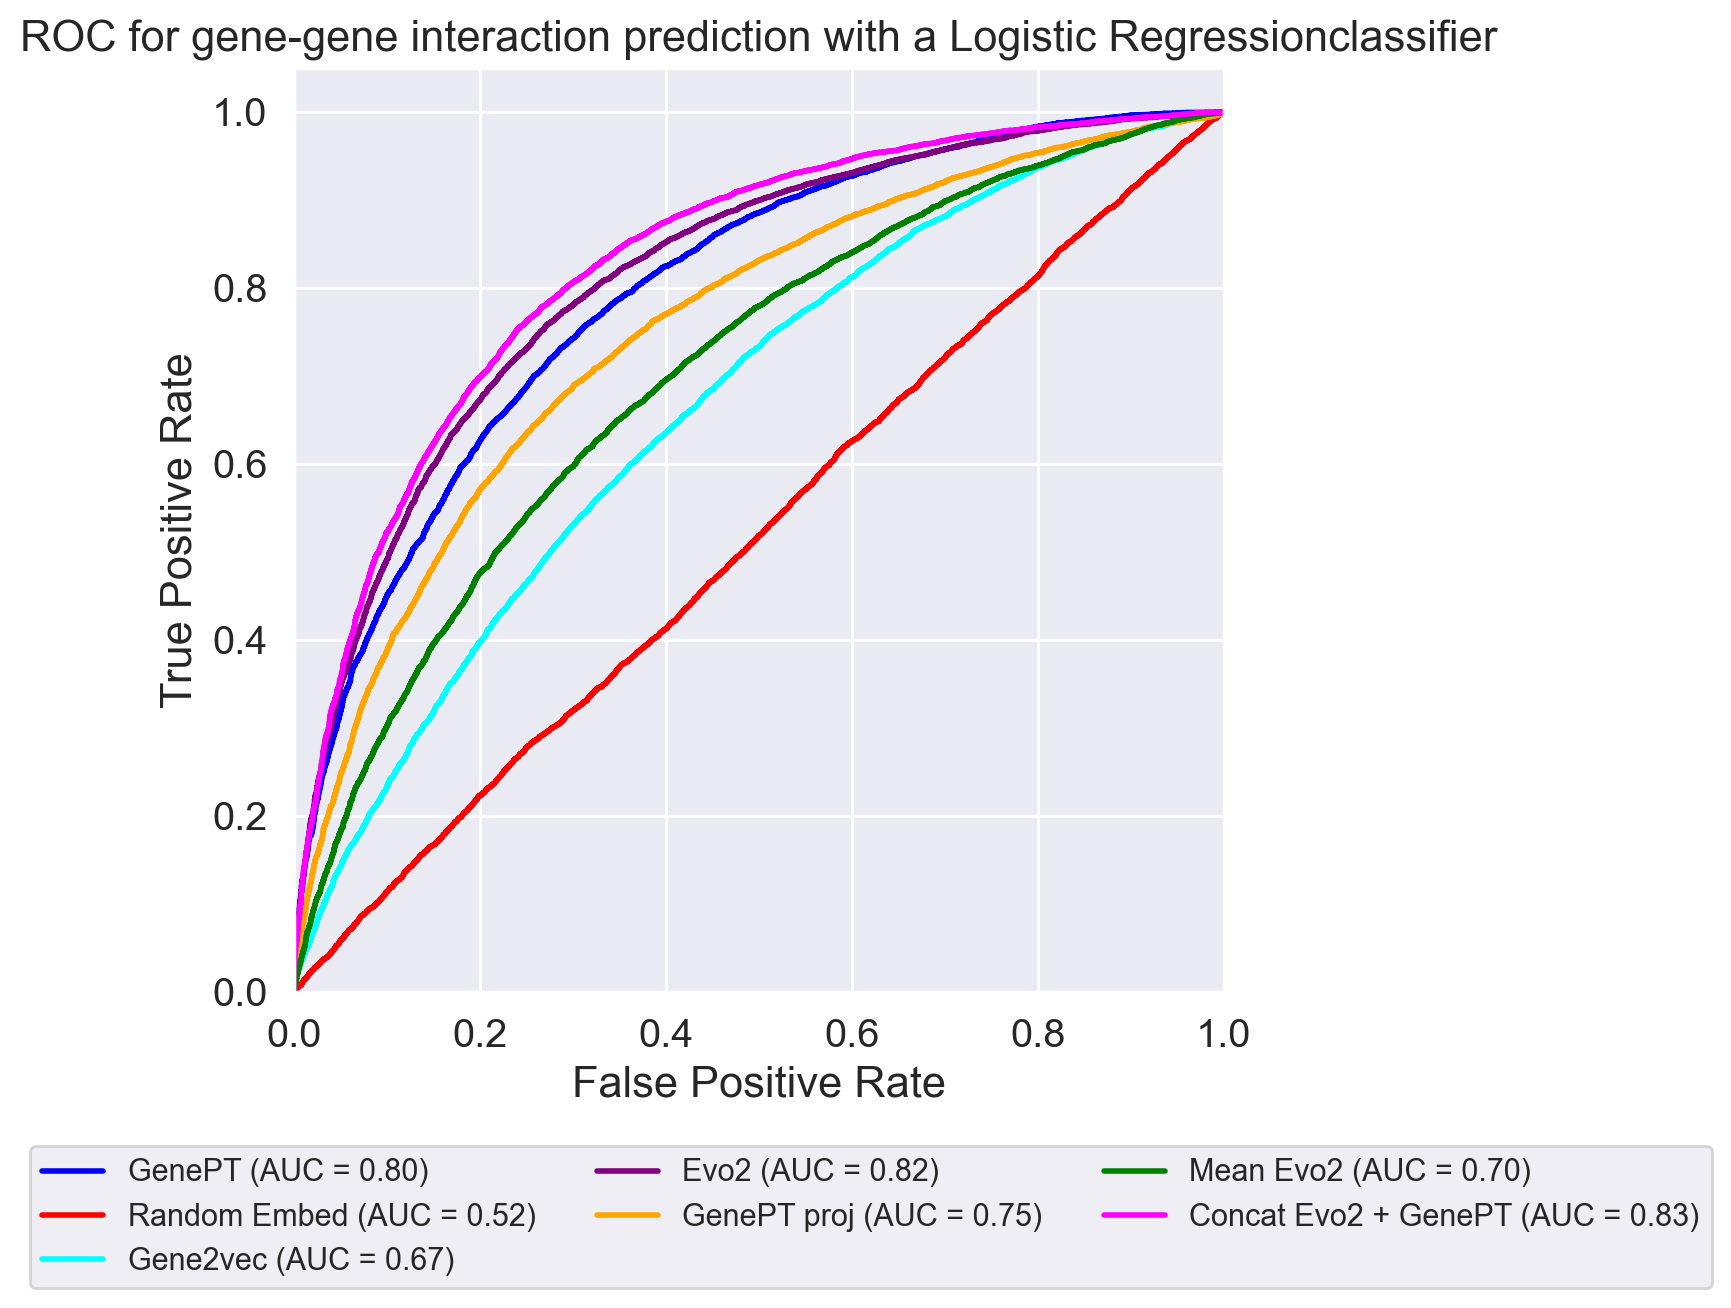

In [56]:
# Plot ROC curves
plt.figure()
# Existing Logistic Regression curves
# ... your existing plot code for Logistic Regression here ...
plt.figure(figsize=(6,6))
# Add Random Forest ROC curves
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2,
         label='GenePT (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test, y_pred_rf[:,1])))
plt.plot(fpr_random_rf, tpr_random_rf, color='red', lw=2,
         label='Random Embed (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_random, y_pred_rf_random[:,1])))
plt.plot(fpr_gene2vec_rf, tpr_gene2vec_rf, color='cyan', lw=2,
         label='Gene2vec (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_gene2vec, y_pred_rf_gene2vec[:,1])))
plt.plot(fpr_evo2_rf, tpr_evo2_rf, color='purple', lw=2,
            label='Evo2 (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_evo2, y_pred_rf_evo2[:,1])))
plt.plot(fpr_genept_rf, tpr_genept_rf, color='orange', lw=2,
            label='GenePT proj (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_genept, y_pred_rf_genept[:,1])))
plt.plot(fpr_mean_evo2_rf, tpr_mean_evo2_rf, color='green', lw=2,
            label='Mean Evo2 (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_mean_evo2, y_pred_rf_mean_evo2[:,1])))
plt.plot(fpr_concat_evo2_genept_rf, tpr_concat_evo2_genept_rf, color='magenta', lw=2,
            label='Concat Evo2 + GenePT (AUC = %0.2f)' % (sklearn.metrics.roc_auc_score(y_array_test_concat_evo2_genept, y_pred_rf_concat_evo2_genept[:,1])))


# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for gene-gene interaction prediction with a Logistic Regressionclassifier')
plt.legend(loc='upper left',bbox_to_anchor=(-0.3, -0.15),fontsize=11,ncol=3)